In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Data Preprocessing

In [2]:
data = pd.read_csv("insurance.csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
data["sex"] = (data["sex"] == "female").astype("int8")
data["smoker"] = (data["smoker"] == "yes").astype("int8")

In [4]:
counts = data["region"].value_counts()
for v in counts.keys():
    data[f"region_{v}"] = (data["region"] == v).astype("int8")
data.drop("region", axis=1, inplace=True)

In [5]:
data

,age,sex,bmi,children,smoker,charges,region_southeast,region_southwest,region_northwest,region_northeast
0,19,1,27.900,0,1,16884.92400,0,1,0,0
1,18,0,33.770,1,0,1725.55230,1,0,0,0
2,28,0,33.000,3,0,4449.46200,1,0,0,0
3,33,0,22.705,0,0,21984.47061,0,0,1,0
4,32,0,28.880,0,0,3866.85520,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,0,1,0
1334,18,1,31.920,0,0,2205.98080,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,1,0,0,0
1336,21,1,25.800,0,0,2007.94500,0,1,0,0


In [6]:
y = data["charges"].values
x = data.drop("charges", axis=1)

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
sc = MinMaxScaler()

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

<class 'pandas.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1070 non-null   int64  
 1   sex               1070 non-null   int8   
 2   bmi               1070 non-null   float64
 3   children          1070 non-null   int64  
 4   smoker            1070 non-null   int8   
 5   region_southeast  1070 non-null   int8   
 6   region_southwest  1070 non-null   int8   
 7   region_northwest  1070 non-null   int8   
 8   region_northeast  1070 non-null   int8   
dtypes: float64(1), int64(2), int8(6)
memory usage: 39.7 KB


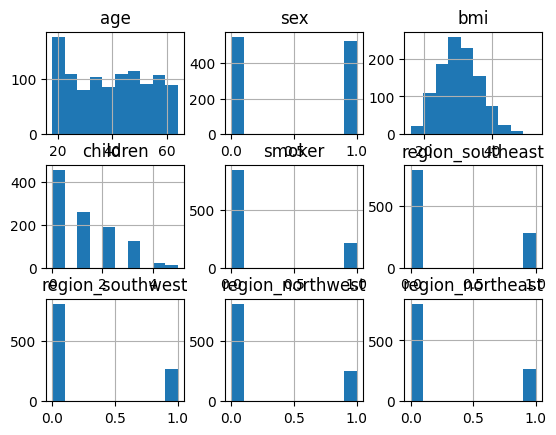

In [9]:
x_train.info(memory_usage=True);
x_train.hist();

<Axes: >

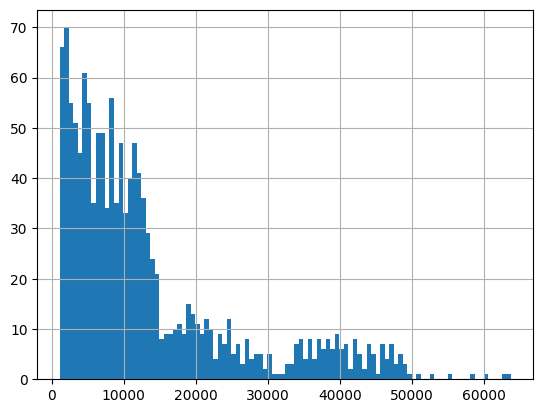

In [10]:
data["charges"].hist(bins=100)

In [11]:
# data["charges"].describe()
np.log(data["charges"]).describe()

count    1338.000000
mean        9.098659
std         0.919527
min         7.022756
25%         8.463853
50%         9.146552
75%         9.719558
max        11.063045
Name: charges, dtype: float64

In [12]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int8   
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int8   
 5   charges           1338 non-null   float64
 6   region_southeast  1338 non-null   int8   
 7   region_southwest  1338 non-null   int8   
 8   region_northwest  1338 non-null   int8   
 9   region_northeast  1338 non-null   int8   
dtypes: float64(2), int64(2), int8(6)
memory usage: 49.8 KB


<Axes: >

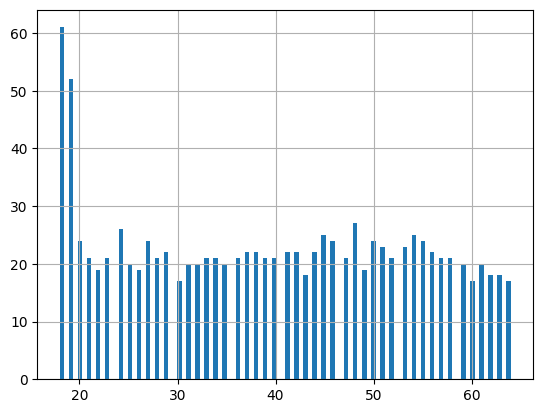

In [14]:
x_train["age"].hist(bins=100)

# Model

## Linear Regression

### Standart

In [15]:
model = LinearRegression()
model.fit(x_train, y_train)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
print(f"Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}, R2 score: {r2_score(y_test, y_test_pred)}")

Train: 0.28204571267478085, Test: 0.26965057295320327, R2 score: 0.8047410791393023


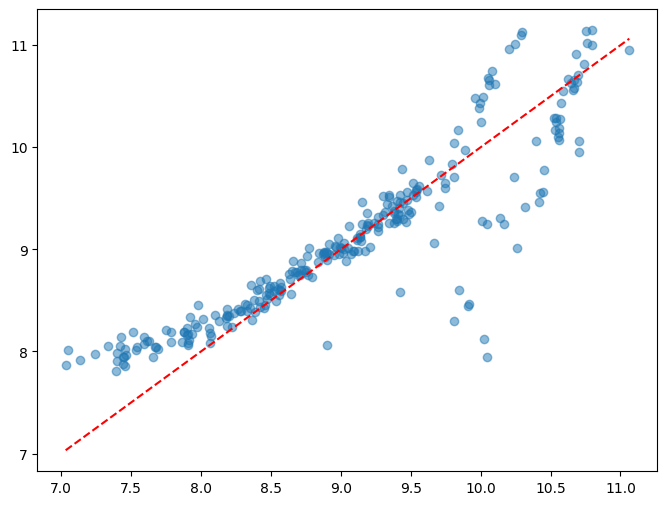

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')

### MinMaxScaler(age, bmi, children)

In [17]:
model = LinearRegression()
model.fit(x_train_sc, y_train)
y_train_pred = model.predict(x_train_sc)
y_test_pred = model.predict(x_test_sc)
print(f"Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}, R2 score: {r2_score(y_test, y_test_pred)}")

Train: 0.282045712674782, Test: 0.2696505729532043, R2 score: 0.804741079139302


Text(0.5, 1.0, 'Polynomial Regression (degree=2) + MinMaxScaling')

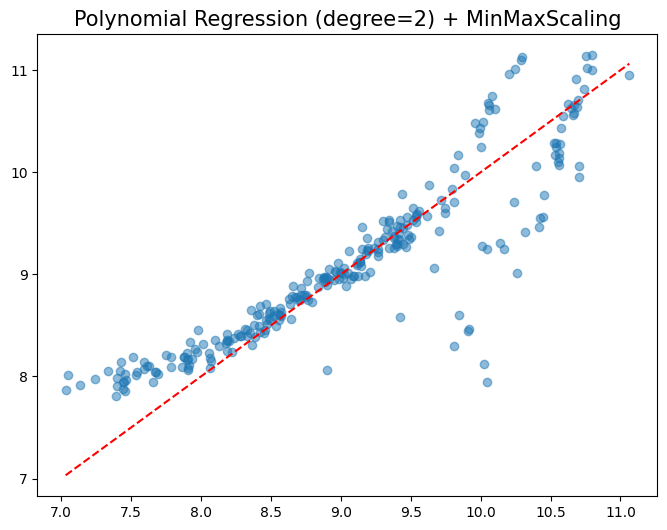

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Polynomial Regression (degree=2) + MinMaxScaling', fontsize=15)

## Polynomial Features

### Standart

In [19]:
poly = PolynomialFeatures(degree=3, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
print(x_train_poly.shape)
model.fit(x_train_poly, y_train)
y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)
print(f"Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}, R2 score: {r2_score(y_test, y_test_pred)}")

(1070, 219)
Train: 0.19696061408032062, Test: 0.20724313231361122, R2 score: 0.8558424882729323


Text(0.5, 1.0, 'Polynomial Regression (degree=2)')

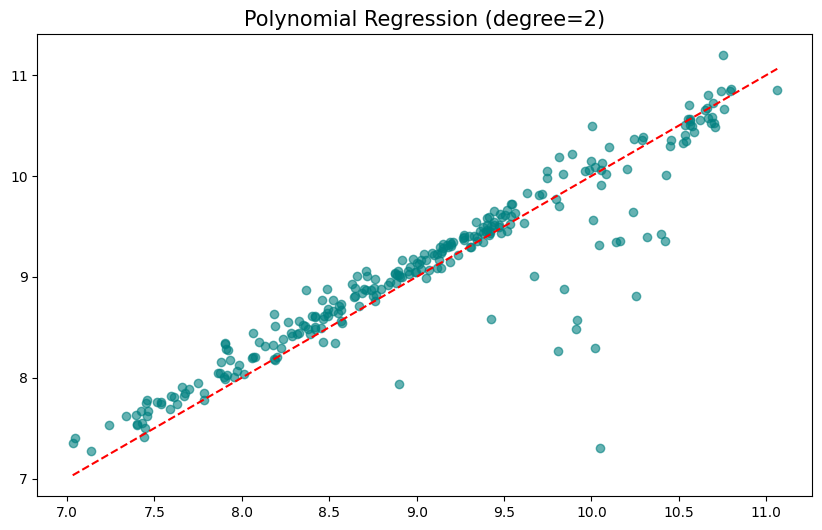

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.title('Polynomial Regression (degree=2)', fontsize=15)

### MinMaxScaler(age, bmi, children)

In [21]:
poly = PolynomialFeatures(degree=3, include_bias=False)
x_train_poly = poly.fit_transform(x_train_sc)
x_test_poly = poly.transform(x_test_sc)
print(x_train_poly.shape)
model.fit(x_train_poly, y_train)
y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)
print(f"Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}, R2 score: {r2_score(y_test, y_test_pred)}")

(1070, 219)
Train: 0.19696061407888613, Test: 0.20724313231023925, R2 score: 0.855842488274503


Text(0.5, 1.0, 'Polynomial Regression (degree=2) + MinMaxScaling')

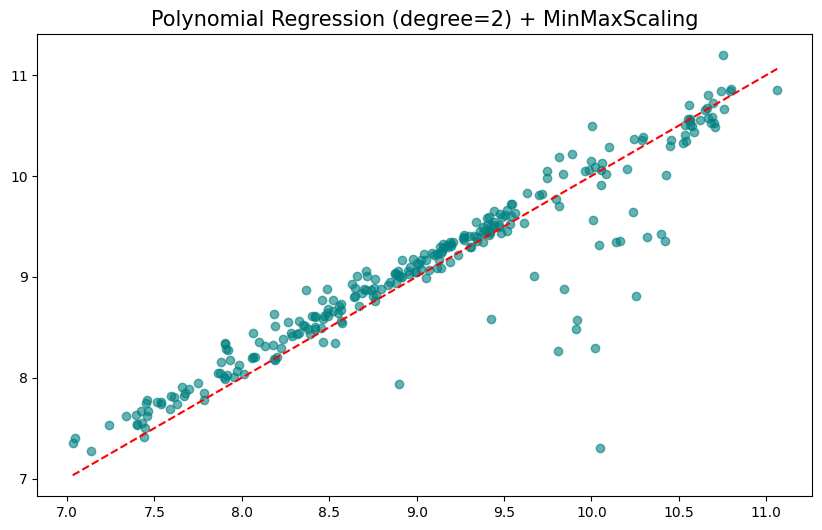

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.title('Polynomial Regression (degree=2) + MinMaxScaling', fontsize=15)